# Figure 5 iMN graphics (6-well)

Notes:

1. Only singlets
2. Reseed at 7 dpi with puro, with full media changes until 1/2 media X on days 11, 12, 13, flow on 14 (7 days with puro)

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

# Load in data

7 dpi flow data

In [ ]:
# Base dir for data files
path = rd.datadir / 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"
# figure path
figpath = "./figures/2025.11.26_DASIT-iMN-purify_1-3/"

# Data path
cache_path_7dpi = path / 'export_singlets_7dpi' /'data_7dpi.gzip'

if cache_path_7dpi.exists():
    df_7dpi = pd.read_parquet(cache_path_7dpi)

else: 
    
    files = Path(path / 'export_singlets_7dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        print(file.name)

        match = re.search('export_(?P<cond>.+)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        if cond == 'Ctrl-neg':
            rep = 0
        elif cond[:3] == 'rep':
            rep = int(cond[3])
            cond = 'main'
            
        df['dpi'] = 7
        df['cond'] = cond
        df['rep'] = rep

        df_list.append(df)

    # Convert list of dfs into single df
    df_7dpi = pd.concat(df_list, ignore_index=True)

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'rep']
    df_7dpi = df_7dpi.loc[:, channel_list]

    # Save shortened df
    # df_7dpi.to_parquet(rd.outfile(cache_path_7dpi))

export_rep1_Singlets.csv
export_rep3_Singlets.csv
export_Ctrl-neg_Singlets.csv
export_rep2_Singlets.csv


Hemocytometer data

In [37]:
df_counts_7dpi = pd.read_excel(open(path/'2025.11.26_7dpi_count.xlsx', 'rb'), sheet_name='summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_7dpi.iterrows():

    df_counts_7dpi.loc[index, 'percent Hb9::EGFP+'] = row['frac Hb9::EGFP+']*100
    df_counts_7dpi.loc[index, 'Cells per 6well'] = row['Cells per 6well [mil]']*1e6
    df_counts_7dpi.loc[index, 'HG cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['frac Hb9::EGFP+']

df_counts_7dpi

,dpi,rep,cond,purifyCond,Total cells [mil],Total 6wells,Cells per 6well [mil],frac Hb9::EGFP+,percent Hb9::EGFP+,Cells per 6well,HG cells per 6well [mil]
0,7,1,main,preReseed,29.0000,10,3.216667,0.42,42.0,3.216667e+06,1.351000
1,7,2,main,preReseed,5.3000,10,2.900000,0.46,46.0,2.900000e+06,1.334000
2,7,3,main,preReseed,26.8125,10,2.316667,0.47,47.0,2.316667e+06,1.088833


# 7 dpi, reseeding data

From 2025.11.26_DASIT-iMN-purify_1-3 >> 2025.11.26_7dpi_count.xlsx

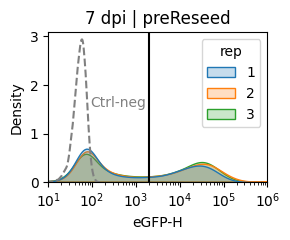

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Threshold for Hb9::GFP
# eGFP_H_thresh = 5e3
eGFP_H_thresh = 2e3
hue = 'rep'
palette = 'tab10'

# Plot eGFP-H
x = 'eGFP-H'
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] != 'Ctrl-neg') & (df_7dpi[x]>0)], # (df_7dpi['rep'] == 1) & 
        ax=ax, x=x, hue=hue,
        common_norm=False, log_scale=(True, False), palette=palette,
        fill=True)


# Plot ctrl-neg
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] == 'Ctrl-neg') & (df_7dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.32, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'7 dpi | preReseed')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'dist-eGFP_7dpi.svg', bbox_inches='tight')

Make new df that is split by cell type (HG+ vs. all) for plotting purposes

In [25]:
# Make a new df split by cell type for plotting
df_counts_7dpi_HG = df_counts_7dpi.copy()
df_counts_7dpi_HG.loc[:, 'cellType'] = 'EGFP+'
df_counts_7dpi_all = df_counts_7dpi.copy()
df_counts_7dpi_all.loc[:, 'cellType'] = 'All'

df_counts_7dpi_split = pd.concat([df_counts_7dpi_all, df_counts_7dpi_HG], ignore_index=True)
df_counts_7dpi_split

# Merge wih data from counts
for index, row in df_counts_7dpi_split.iterrows():
    if row['cellType'] == 'EGFP+':
        df_counts_7dpi_split.loc[index, 'Cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['frac Hb9::EGFP+']

df_counts_7dpi_split.loc[:, 'Cells per 6well'] = df_counts_7dpi_split.loc[:, 'Cells per 6well [mil]']*1e6 

df_counts_7dpi_split

,dpi,rep,cond,purifyCond,Total cells [mil],Total 6wells,Cells per 6well [mil],frac Hb9::EGFP+,HG cells per 6well [mil],cellType,Cells per 6well
0,7,1,main,preReseed,29.0000,10,3.216667,0.42,1.351000,All,3.216667e+06
1,7,2,main,preReseed,5.3000,10,2.900000,0.46,1.334000,All,2.900000e+06
2,7,3,main,preReseed,26.8125,10,2.316667,0.47,1.088833,All,2.316667e+06
3,7,1,main,preReseed,29.0000,10,1.351000,0.42,1.351000,EGFP+,1.351000e+06
4,7,2,main,preReseed,5.3000,10,1.334000,0.46,1.334000,EGFP+,1.334000e+06
5,7,3,main,preReseed,26.8125,10,1.088833,0.47,1.088833,EGFP+,1.088833e+06


Text(0.5, 1.0, '(#) Cells per 6-well\n(75k seed)')

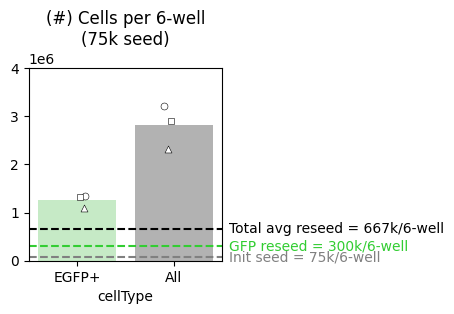

In [20]:
# General plotting params
x = 'cellType'
y = 'Cells per 6well'
order = ['EGFP+', 'All']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

# palette = {'All': 'black', 'EGFP+': 'limegreen'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

sns.barplot(
    ax=ax, data=df_counts_7dpi_split, 
    x=x, y=y, 
    order=order,
    ci=None,
    palette=palette, alpha=0.3)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_7dpi_split.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_7dpi_split[(df_counts_7dpi_split.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

ax.yaxis.set_label_text('')
ax.set_ylim([0, 3.5e6])
ax.set_yticks(np.arange(0, 4e6+1, 1e6))

# Annotate lines
init_seed = 75e3 # 75k MEFs/6-well init seed
GFP_reseed = 0.3e6 # 300k Hb9::EGFP+/6-well reseed at 7 dpi
frac_EGFP = df_counts_7dpi.loc[:,'frac Hb9::EGFP+'].mean()
total_reseed = GFP_reseed/frac_EGFP # How many total cells/6-well reseed at 7 dpi
init_seed_color = 'grey'
GFP_reseed_color = 'limegreen'
total_reseed_color = 'black'
ax.axhline(init_seed, 0, 1, color=init_seed_color, linestyle='--')
ax.axhline(GFP_reseed, 0, 1, color=GFP_reseed_color, linestyle='--')
ax.axhline(total_reseed, 0, 1, color=total_reseed_color, linestyle='--')

ax.annotate(f'Init seed = {init_seed/1e3:.0f}k/6-well', 
            xy=(1, init_seed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=init_seed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'GFP reseed = {GFP_reseed/1e3:.0f}k/6-well', 
            xy=(1, GFP_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=GFP_reseed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'Total avg reseed = {total_reseed/1e3:.0f}k/6-well',
            xy=(1, total_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=total_reseed_color, verticalalignment='center', horizontalalignment='left')

# h,l = ax1.get_legend_handles_labels()
# sns.move_legend(ax1, title='Seed by cond', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


plt.title('(#) Cells per 6-well\n(75k seed)')
# plt.savefig(figpath + f'7dpi_cellcounts.svg', bbox_inches='tight')

In [38]:
df_counts_7dpi

,dpi,rep,cond,purifyCond,Total cells [mil],Total 6wells,Cells per 6well [mil],frac Hb9::EGFP+,percent Hb9::EGFP+,Cells per 6well,HG cells per 6well [mil]
0,7,1,main,preReseed,29.0000,10,3.216667,0.42,42.0,3.216667e+06,1.351000
1,7,2,main,preReseed,5.3000,10,2.900000,0.46,46.0,2.900000e+06,1.334000
2,7,3,main,preReseed,26.8125,10,2.316667,0.47,47.0,2.316667e+06,1.088833


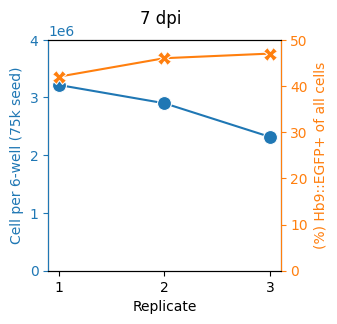

In [52]:
# General plotting params
x = 'rep'

# Plot
fig, ax1 = plt.subplots(1, 1, figsize=(3,3))

y1 = 'Cells per 6well'
color1 = 'tab:blue'
sns.lineplot(
    ax=ax1, data=df_counts_7dpi,
    x=x, y=y1,
    marker='o', markersize=10, color=color1)

y2 = 'percent Hb9::EGFP+'
color2 = 'tab:orange'
ax2 = ax1.twinx()
sns.lineplot(
    ax=ax2, data=df_counts_7dpi,
    x=x, y=y2,
    marker='X', markersize=10, color=color2, legend=False)

ax1.yaxis.set_label_text('Cell per 6-well (75k seed)', color=color1)
ax1.tick_params(axis='y', colors=color1)
# ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1e6:.0f}e6'))
ax1.set_yticks(np.arange(0, 4.1e6, 1e6))
ax1.set_ylim([0, 4e6])

ax2.yaxis.set_label_text('(%) Hb9::EGFP+ of all cells', color=color2)
ax2.tick_params(axis='y', colors=color2)

ax2.spines['left'].set_color(color1)
ax2.spines['right'].set_color(color2)
ax2.set_ylim([0, 50])

ax1.set_xticks(np.arange(1, 4, 1))
ax1.set_xlabel('Replicate')

plt.suptitle(f'7 dpi')
plt.savefig(figpath + f'7dpi_cellCount-Hb9percent.svg', bbox_inches='tight')

# Post-selection

## Load data

In [7]:
# Base dir for data files
path = rd.datadir / 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"
figpath = "./figures/2025.11.26_DASIT-iMN-purify_1-3/"

# Data path
cache_path_14dpi = path / 'export_singlets_14dpi' /'data_14dpi.gzip'

if cache_path_14dpi.exists():
    df_14dpi = pd.read_parquet(cache_path_14dpi)
    # df_all = pd.read_parquet( path/'data_all.gzip')

else: 
    
    files = Path(path / 'export_singlets_14dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        match = re.search('export_(?P<cond>.+)_(?P<purify>.+)_(?P<rep>\d)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        purify = match.group('purify')
        rep = match.group('rep')

        if purify[:4] == 'puro':
            puro = float(purify[4:])
            cond = "postPuro"
        else:
            puro = 0

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        df['dpi'] = 14
        df['cond'] = cond
        df['purify'] = purify
        df['rep'] = int(rep)
        
        df_list.append(df)

    # Convert list of dfs into single df
    df_14dpi = pd.concat(df_list, ignore_index=True)

    # # Convert puro to int
    # df_all = df_all.astype({'puro': 'int'})

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'purify', 'rep']
    df_14dpi = df_14dpi.loc[:, channel_list]

    # Save shortened df
    df_14dpi.to_parquet(rd.outfile(cache_path_14dpi))

Hemocytometer data

In [235]:
df_counts_14dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='14 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_14dpi.iterrows():

    df_counts_14dpi.loc[index, 'cond.purifyCond'] = row['cond'] + "." + row['purifyCond']
    df_counts_14dpi.loc[index, 'Hb9::EGFP+ [%]'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_14dpi.loc[index, 'Total # cells'] = row['Total # cells [k]']*1e3
    df_counts_14dpi.loc[index, 'Cells per 6well'] = df_counts_14dpi.loc[index, 'Total # cells']/row['Total 6wells dissociated']
    df_counts_14dpi.loc[index, 'HG cells per 6well'] = df_counts_14dpi.loc[index, 'Cells per 6well']*row['Hb9::EGFP+ [frac]']

df_counts_14dpi

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Total # cells [k],Hb9::EGFP+ [frac],Unnamed: 7,cond.purifyCond,Hb9::EGFP+ [%],Total # cells,Cells per 6well,HG cells per 6well
0,14,1,DASIT,puro0,2,1100.000000,0.35,NaN,DASIT.puro0,35.0,1.100000e+06,5.500000e+05,192500.0
1,14,1,DASIT,puro10,1,195.000000,0.70,NaN,DASIT.puro10,70.0,1.950000e+05,1.950000e+05,136500.0
2,14,1,DASIT,puro50,2,316.666667,0.99,NaN,DASIT.puro50,99.0,3.166667e+05,1.583333e+05,156750.0
3,14,1,DASIT,puro100,1,2.500000,0.88,NaN,DASIT.puro100,88.0,2.500000e+03,2.500000e+03,2200.0
4,14,1,noReseed,preFACS,1,3287.500000,0.41,NaN,noReseed.preFACS,41.0,3.287500e+06,3.287500e+06,1347875.0
5,14,2,DASIT,puro0,2,925.000000,0.30,NaN,DASIT.puro0,30.0,9.250000e+05,4.625000e+05,138750.0
6,14,2,DASIT,puro10,1,92.500000,0.77,NaN,DASIT.puro10,77.0,9.250000e+04,9.250000e+04,71225.0
7,14,2,DASIT,puro50,2,225.000000,0.99,NaN,DASIT.puro50,99.0,2.250000e+05,1.125000e+05,111375.0
8,14,2,DASIT,puro100,1,5.000000,0.89,NaN,DASIT.puro100,89.0,5.000000e+03,5.000000e+03,4450.0
9,14,2,noReseed,preFACS,1,2112.500000,0.38,NaN,noReseed.preFACS,38.0,2.112500e+06,2.112500e+06,802750.0


## Look at iMN purity without reseed

### eGFP threshold and distribution

In [18]:
df_14dpi.cond.unique()

array(['postPuro', 'noReseed', 'Ctrl-neg'], dtype=object)

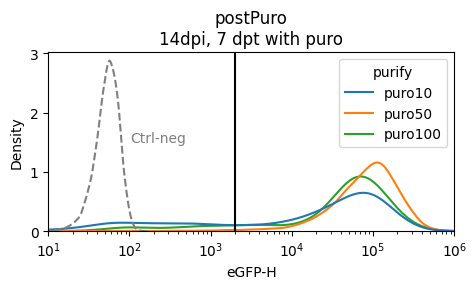

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
# eGFP_H_thresh = 5e3
eGFP_H_thresh = 2e3

# Plot eGFP-H
x = 'eGFP-H'
cond = 'postPuro'
hue = 'purify'
hue_order = ['puro10', 'puro50', 'puro100']
rep = 1
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == cond) & (df_14dpi[x]>0) & (df_14dpi['rep']==rep)],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=False)


# Plot ctrl-neg
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == 'Ctrl-neg') & (df_14dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.27, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'{cond}\n14dpi, 7 dpt with puro')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'dist-eGFP_14dpi_{cond}_{rep}.svg', bbox_inches='tight')

In [31]:
df_14dpi

,eGFP-H,dpi,cond,purify,rep
0,65,14,postPuro,puro10,1
1,1842,14,postPuro,puro10,1
2,42338,14,postPuro,puro10,1
3,1331,14,postPuro,puro10,1
4,86212,14,postPuro,puro10,1
...,...,...,...,...,...
188776,229196,14,postPuro,puro100,3
188777,84750,14,postPuro,puro100,3
188778,49095,14,postPuro,puro100,3
188779,49770,14,postPuro,puro100,3


In [44]:
# Categorize iMNs based on eGFP_thresh
df_14dpi['eGFP_cat'] = np.where(df_14dpi['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib') 

# Get total counts and percent of GFP-H+
group = ['dpi', 'cond', 'purify']
count_df_reps = df_14dpi.groupby([*group, 'rep', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
data_iMN_percent_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'rep']).transform('sum')).reset_index(name='percent')

# Extract just the iMNs
data_iMN_percent_reps = data_iMN_percent_reps.loc[(data_iMN_percent_reps['eGFP_cat'] == 'iMN')]

In [51]:
data_iMN_percent_reps[data_iMN_percent_reps.rep == 1]

,dpi,cond,purify,rep,eGFP_cat,percent
1,14,Ctrl-neg,Ctrl-neg,1,iMN,0.000000
3,14,noReseed,postFACS,1,iMN,87.078533
9,14,noReseed,preFACS,1,iMN,42.722022
15,14,postPuro,puro10,1,iMN,70.469507
21,14,postPuro,puro100,1,iMN,88.180404
27,14,postPuro,puro50,1,iMN,98.889461


## Purity

In [61]:
df_counts_14dpi

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Total # cells [k],Hb9::EGFP+ [frac],Hb9::EGFP+ [%],Total # cells,Cells per 6well
0,14,1,DASIT,puro0,2,330.000000,0.35,35.0,330000.000000,165000.000000
1,14,1,DASIT,puro10,1,195.000000,0.70,70.0,195000.000000,195000.000000
2,14,1,DASIT,puro50,1,40.000000,0.99,99.0,40000.000000,40000.000000
3,14,1,DASIT,puro100,1,2.500000,0.88,88.0,2500.000000,2500.000000
4,14,1,noReseed,preFACS,1,986.250000,0.41,41.0,986250.000000,986250.000000
5,14,2,DASIT,puro0,2,277.500000,0.30,30.0,277500.000000,138750.000000
6,14,2,DASIT,puro10,1,92.500000,0.77,77.0,92500.000000,92500.000000
7,14,2,DASIT,puro50,1,62.500000,0.99,99.0,62500.000000,62500.000000
8,14,2,DASIT,puro100,1,5.000000,0.89,89.0,5000.000000,5000.000000
9,14,2,noReseed,preFACS,1,633.750000,0.38,38.0,633750.000000,633750.000000


/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


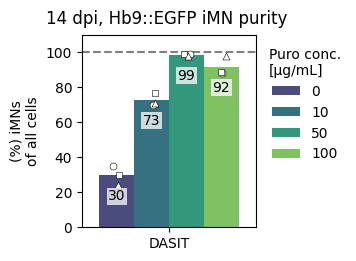

In [132]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['DASIT']
hue = 'purifyCond'
hue_order = ['puro0', 'puro10', 'puro50', 'puro100']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = 'viridis'

label_dict = {'puro0':'0', 'puro10':'10', 'puro50':'50', 'puro100':'100'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)
    

# # Add in stats
# # Pairs for stats comp
# pairs = [(('DASIT', 'puro0'), ('DASIT', 'puro50'))]
# annot = Annotator(ax=ax,
#     data=df_counts_14dpi, pairs=pairs,
#     x=x, y=y, hue=hue,
#     order=order, hue_order=hue_order)
# annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
# annot.apply_test().annotate(line_offset_to_group=0.05)

# legend
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
    title='Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-purity_DASIT.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


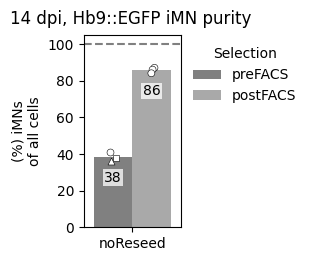

In [142]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
    title='Selection', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-purity_noReseed.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


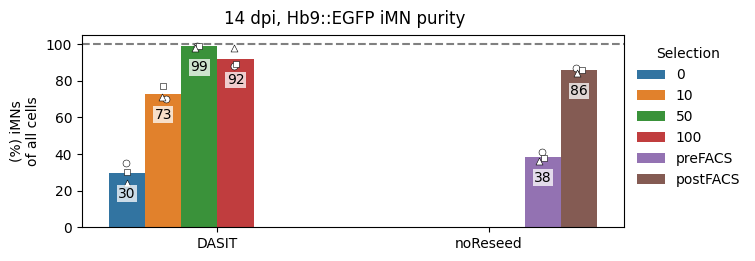

In [197]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['DASIT', 'noReseed']
hue = 'purifyCond'
hue_order = ['puro0', 'puro10', 'puro50', 'puro100', 'preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'puro0':'0', 'puro10':'10', 'puro50':'50', 'puro100':'100', 'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(7,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
    title='Selection', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-purity_DASIT-noReseed.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

noReseed.noReseed-postFACS vs. DASIT.puro50: t-test independent samples with Bonferroni correction, P_val:1.603e-04 t=-1.379e+01


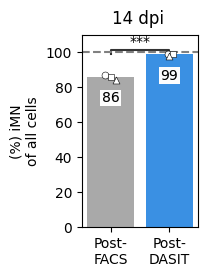

In [ ]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN\nof all cells')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-purity-final.svg', bbox_inches='tight')

## Count

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


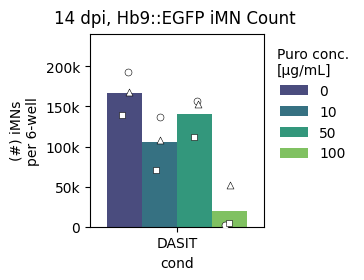

In [ ]:
# General plotting params
x = 'cond'
y = 'HG cells per 6well'
order = ['DASIT']
hue = 'purifyCond'
hue_order = ['puro0', 'puro10', 'puro50', 'puro100']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = 'viridis'

label_dict = {'puro0':'0', 'puro10':'10', 'puro50':'50', 'puro100':'100'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
    title='Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
 

# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
# ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 240e3])


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN Count')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-count_DASIT.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


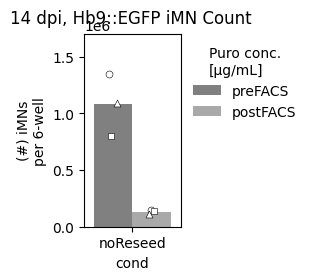

In [ ]:
# General plotting params
x = 'cond'
y = 'HG cells per 6well'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
    title='Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
 

# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
# ax.xaxis.set_label_text('')
# ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 1.7e6])


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN Count')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-count_noReseed.svg', bbox_inches='tight')

Text(0.5, 0.98, '14 dpi, Hb9::EGFP iMN Count')

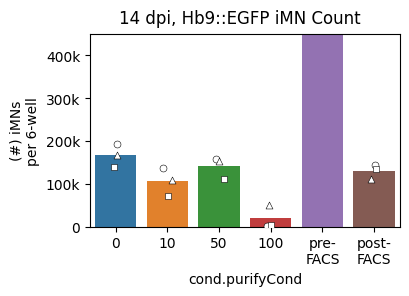

In [265]:
# General plotting params
x = 'cond.purifyCond'
y = 'HG cells per 6well'
order = ['DASIT.puro0', 'DASIT.puro10', 'DASIT.puro50', 'DASIT.puro100', 'noReseed.preFACS', 'noReseed.noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro0':'0', 'DASIT.puro10':'10', 'DASIT.puro50':'50', 'DASIT.puro100':'100', 'noReseed.preFACS':'pre-\nFACS', 'noReseed.noReseed-postFACS':'post-\nFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(4,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# legend
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=[label_dict[j] for j in l[-len(hue_order):]],
#     title='Selection', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.set_xticklabels([label_dict[l] for l in order])

# # Add in stats
# # Pairs for stats comp
# pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
# annot = Annotator(ax=ax,
#     data=df_counts_14dpi, pairs=pairs,
#     x=x, y=y,
#     order=order)
# annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
# annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
# ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 450e3])

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN Count')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'bar_iMN-count_DASIT-noReseed.svg', bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

noReseed.noReseed-postFACS vs. DASIT.puro50: t-test independent samples with Bonferroni correction, P_val:2.982e-03 t=-6.445e+00


/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statan

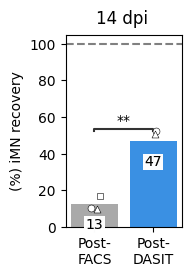

In [275]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ recovery [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN recovery')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
# fig.tight_layout()  # Helps improve white spacing
plt.savefig(figpath + f'bar_iMN-recovery.svg', bbox_inches='tight')